In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## Etapa 1 — Importação de Bibliotecas

Antes de qualquer análise, precisamos carregar as ferramentas que vamos usar.
Em Python, essas ferramentas são chamadas de **bibliotecas**.

- **pandas**: manipulação de tabelas de dados (nosso principal instrumento)
- **numpy**: operações matemáticas e numéricas
- **matplotlib**: criação de gráficos
- **seaborn**: gráficos mais bonitos e prontos para apresentação

O `import ... as` é apenas um apelido — em vez de escrever `pandas` toda vez,
escrevemos só `pd`. É uma convenção universal na área de dados.

In [22]:
df = pd.read_csv('cs-training.csv', index_col=0)

print(f"Dataset carregado: {df.shape[0]:,} linhas e {df.shape[1]} colunas")
df.head()

Dataset carregado: 150,000 linhas e 11 colunas


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Etapa 2 — Carregamento dos Dados

Aqui carregamos o arquivo CSV para dentro do Python.
O pandas transforma o arquivo em um objeto chamado **DataFrame** — 
pense nele como uma planilha do Excel, mas dentro do Python.

- `pd.read_csv()`: lê o arquivo e cria o DataFrame
- `index_col=0`: diz que a primeira coluna é o índice das linhas (numeração)
- `df.shape`: retorna (linhas, colunas) — como se perguntasse o "tamanho" da tabela
- `df.head()`: mostra as 5 primeiras linhas — útil para checar se carregou certo

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

## Etapa 3 — Informações Gerais do Dataset

O método `df.info()` é como um "raio-x" do dataset. Ele mostra:

- O nome de cada coluna
- Quantos valores não-nulos existem (ou seja, quantos estão preenchidos)
- O tipo de dado de cada coluna:
  - **int64**: números inteiros (ex: idade, quantidade)
  - **float64**: números decimais (ex: renda, percentuais)
  - **object**: texto

Se o total de "non-null" for menor que 150.000, significa que 
aquela coluna tem valores ausentes — e isso precisará ser tratado.

In [24]:
ausentes = df.isnull().sum()
ausentes_pct = (ausentes / len(df) * 100).round(2)

resumo = pd.DataFrame({
    'Ausentes': ausentes,
    '% do Total': ausentes_pct
}).query('Ausentes > 0')

print(resumo)

                    Ausentes  % do Total
MonthlyIncome          29731       19.82
NumberOfDependents      3924        2.62


## Etapa 4 — Análise de Valores Ausentes

Valores ausentes (NaN = "Not a Number") são campos em branco no dataset.
Eles são um problema porque os algoritmos de machine learning 
**não conseguem trabalhar com campos vazios** — precisamos tratá-los.

Aqui calculamos:
- Quantos valores estão faltando em cada coluna
- Qual o percentual isso representa do total de 150.000 registros

Isso vai nos guiar na próxima etapa (limpeza dos dados).

Adimplentes (0):   139,974 (93.3%)
Inadimplentes (1): 10,026 (6.7%)


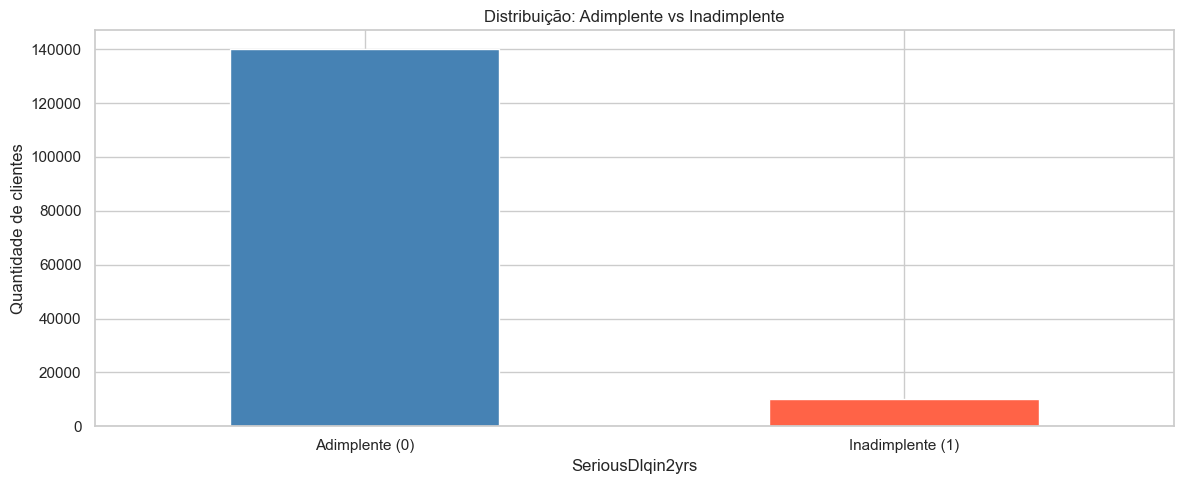

In [25]:
contagem = df['SeriousDlqin2yrs'].value_counts()
pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(f"Adimplentes (0):   {contagem[0]:,} ({pct[0]:.1f}%)")
print(f"Inadimplentes (1): {contagem[1]:,} ({pct[1]:.1f}%)")

df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
plt.title('Distribuição: Adimplente vs Inadimplente')
plt.xticks([0, 1], ['Adimplente (0)', 'Inadimplente (1)'], rotation=0)
plt.ylabel('Quantidade de clientes')
plt.tight_layout()
plt.savefig('grafico1_distribuicao_target.png', dpi=150)
plt.show()

## Etapa 5 — Distribuição do Target (Variável Alvo)

O **target** é a coluna que queremos prever: `SeriousDlqin2yrs`
- **0** = cliente adimplente (pagou em dia)
- **1** = cliente inadimplente (atrasou mais de 90 dias)

Essa análise é fundamental porque datasets de crédito são quase sempre
**desbalanceados** — a maioria dos clientes paga em dia, e poucos ficam
inadimplentes. Isso impacta diretamente como vamos treinar o modelo.

O gráfico vai deixar isso visualmente claro.

Ótimo! Vamos à Etapa 2 — Limpeza dos Dados.
## Etapa 2 — Limpeza dos Dados

Agora que sabemos onde estão os problemas, vamos tratá-los.
Esta etapa é chamada de **Data Cleaning** e é uma das mais importantes
em qualquer projeto de dados — dados sujos geram modelos ruins.

Vamos resolver 3 problemas:
1. Preencher valores ausentes de MonthlyIncome e NumberOfDependents
2. Remover outliers absurdos (ex: idade = 0)
3. Confirmar que o dataset está pronto para o modelo

In [26]:
# Calculamos a mediana de cada coluna com ausentes
# Mediana = valor do meio da distribuição (menos sensível a valores extremos)
mediana_renda = df['MonthlyIncome'].median()
mediana_dependentes = df['NumberOfDependents'].median()

print(f"Mediana de MonthlyIncome:      $ {mediana_renda:,.0f}")
print(f"Mediana de NumberOfDependents: {mediana_dependentes}")

# Preenchemos os valores ausentes com a mediana de cada coluna
# fillna() = "preencha os NaN com este valor"
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(mediana_renda)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mediana_dependentes)

# Confirmamos que não sobrou nenhum valor ausente
print(f"\nValores ausentes restantes: {df.isnull().sum().sum()}")

Mediana de MonthlyIncome:      $ 5,400
Mediana de NumberOfDependents: 0.0

Valores ausentes restantes: 0


In [27]:
# Outliers são valores absurdos que distorcem o modelo
# Vamos checar as colunas mais suspeitas

print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(df[['age', 'MonthlyIncome', 'DebtRatio', 
          'RevolvingUtilizationOfUnsecuredLines']].describe().round(2))

=== ESTATÍSTICAS DESCRITIVAS ===
             age  MonthlyIncome  DebtRatio  \
count  150000.00      150000.00  150000.00   
mean       52.30        6418.45     353.01   
std        14.77       12890.40    2037.82   
min         0.00           0.00       0.00   
25%        41.00        3903.00       0.18   
50%        52.00        5400.00       0.37   
75%        63.00        7400.00       0.87   
max       109.00     3008750.00  329664.00   

       RevolvingUtilizationOfUnsecuredLines  
count                             150000.00  
mean                                   6.05  
std                                  249.76  
min                                    0.00  
25%                                    0.03  
50%                                    0.15  
75%                                    0.56  
max                                50708.00  


### Entendendo o describe()

O método describe() retorna um resumo estatístico de cada coluna:
- **count**: quantos valores preenchidos
- **mean**: média
- **std**: desvio padrão (o quanto os valores variam)
- **min / max**: menor e maior valor
- **25% / 50% / 75%**: quartis — dividem os dados em 4 partes iguais

Preste atenção nos valores de **min** e **max** — 
valores absurdos como idade = 0 ou renda = 99999999 
são sinais de outliers que precisamos tratar.

In [28]:
# Verificando casos suspeitos antes de remover
print(f"Clientes com idade <= 0: {(df['age'] <= 0).sum()}")
print(f"Clientes com idade > 100: {(df['age'] > 100).sum()}")
print(f"Clientes com DebtRatio > 1000: {(df['DebtRatio'] > 1000).sum()}")
print(f"Clientes com RevolvingUtilization > 1: {(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()}")

# Removemos apenas os casos claramente impossíveis
# idade = 0 não existe, idade > 100 é improvável em dataset de crédito
linhas_antes = len(df)
df = df[df['age'] > 0]
linhas_depois = len(df)

print(f"\nLinhas removidas: {linhas_antes - linhas_depois}")
print(f"Dataset final: {len(df):,} linhas")

Clientes com idade <= 0: 1
Clientes com idade > 100: 13
Clientes com DebtRatio > 1000: 16892
Clientes com RevolvingUtilization > 1: 3321

Linhas removidas: 1
Dataset final: 149,999 linhas


In [29]:
# Checagem final: sem ausentes, tamanho correto, tipos corretos
print("=== CHECAGEM FINAL ===")
print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Valores ausentes: {df.isnull().sum().sum()}")
print(f"\nTipos de dados:")
print(df.dtypes)

=== CHECAGEM FINAL ===
Linhas: 149,999
Colunas: 11
Valores ausentes: 0

Tipos de dados:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


## Etapa 3 — Feature Engineering

Feature Engineering significa "criar novas variáveis a partir das existentes".

Por que fazer isso? Porque às vezes a combinação de duas colunas
conta uma história melhor do que cada uma separada.

Exemplo: saber que alguém tem DebtRatio = 0.8 e MonthlyIncome = 1000
é mais revelador do que saber cada número isolado —
essa pessoa deve 80% de uma renda muito baixa, o que é crítico.

Vamos criar 3 novas features que fazem sentido no contexto de crédito.

In [30]:
# Feature 1: Dívida mensal estimada em reais
# DebtRatio = dívida / renda, então dívida = DebtRatio × renda
# Clientes com renda baixa e DebtRatio alto são os mais arriscados
df['DebtMonthly'] = df['DebtRatio'] * df['MonthlyIncome']

# Feature 2: Total de vezes que atrasou (qualquer prazo)
# Somamos todos os tipos de atraso em uma única variável
df['TotalLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                   df['NumberOfTime60-89DaysPastDueNotWorse'] +
                   df['NumberOfTimes90DaysLate'])

# Feature 3: Renda por dependente
# Divide a renda pelo número de pessoas que dependem dela
# Evitamos divisão por zero somando 1 no denominador
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

print("Novas features criadas!")
print(f"Dataset agora tem {df.shape[1]} colunas")
print(df[['DebtMonthly', 'TotalLate', 'IncomePerDependent']].head())

Novas features criadas!
Dataset agora tem 14 colunas
   DebtMonthly  TotalLate  IncomePerDependent
1  7323.197016          2              3040.0
2   316.878123          0              1300.0
3   258.914887          2              3042.0
4   118.963951          0              3300.0
5  1584.975094          1             63588.0


=== CORRELAÇÃO COM INADIMPLÊNCIA ===
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
TotalLate                               0.1155
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0469
RevolvingUtilizationOfUnsecuredLines   -0.0018
NumberRealEstateLoansOrLines           -0.0070
DebtMonthly                            -0.0073
DebtRatio                              -0.0076
MonthlyIncome                          -0.0172
IncomePerDependent                     -0.0266
NumberOfOpenCreditLinesAndLoans        -0.0297
age                                    -0.1154
Name: SeriousDlqin2yrs, dtype: float64


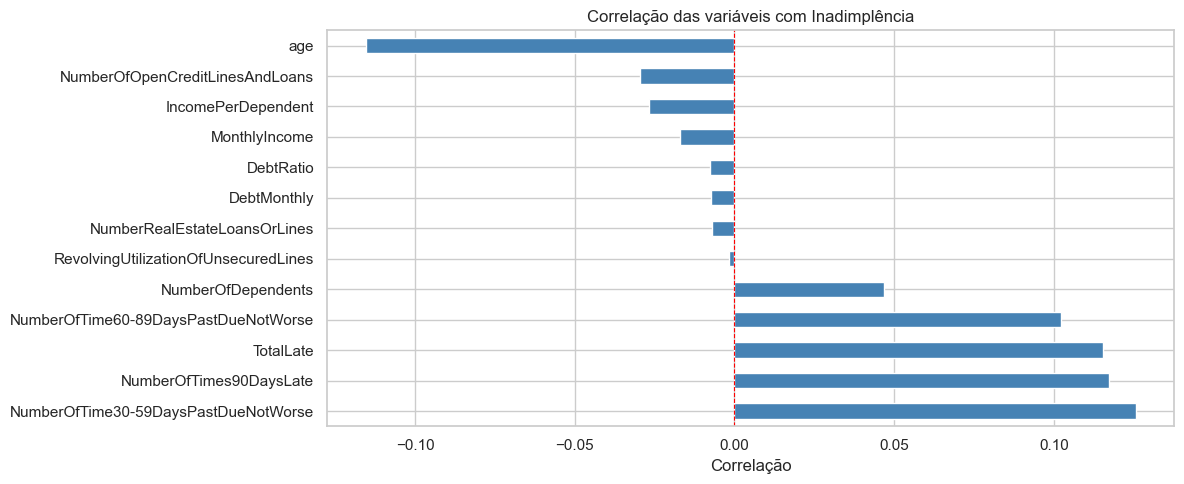

In [31]:
# Correlação mede o quanto cada variável está relacionada com a inadimplência
# Valores próximos de 1 ou -1 = forte relação
# Valores próximos de 0 = pouca relação

correlacoes = df.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
correlacoes = correlacoes.sort_values(ascending=False)

print("=== CORRELAÇÃO COM INADIMPLÊNCIA ===")
print(correlacoes.round(4))

# Gráfico de barras horizontais
correlacoes.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Correlação das variáveis com Inadimplência')
plt.xlabel('Correlação')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('grafico2_correlacoes.png', dpi=150)
plt.show()

## Etapa 4 — Treinamento do Modelo (Random Forest)

Chegamos à etapa principal: treinar o modelo de Machine Learning.

### O que é um Random Forest?
Imagine que você quer decidir se vai emprestar dinheiro para alguém.
Você consulta 100 analistas de crédito diferentes, cada um analisa
os dados do cliente e dá seu voto: "empresta" ou "não empresta".
A decisão final é a que a maioria votou.

É exatamente isso que o Random Forest faz:
- Cria centenas de "árvores de decisão" (os analistas)
- Cada árvore analisa uma parte dos dados
- A decisão final é por votação da maioria

### Divisão treino / teste
Antes de treinar, dividimos o dataset em 2 partes:
- **80% treino**: o modelo aprende com esses dados
- **20% teste**: usamos para medir se ele realmente aprendeu

Isso evita "cola" — o modelo não pode ser avaliado nos mesmos 
dados que usou para aprender.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# X = variáveis que o modelo vai usar para aprender (features)
# y = o que queremos prever (target)
X = df.drop(columns=['SeriousDlqin2yrs'])  # tudo exceto o target
y = df['SeriousDlqin2yrs']                 # apenas o target

print(f"Features (X): {X.shape[1]} colunas")
print(f"Target (y): {y.shape[0]:,} registros")
print(f"\nColunas usadas no modelo:")
for col in X.columns:
    print(f"  - {col}")

Features (X): 13 colunas
Target (y): 149,999 registros

Colunas usadas no modelo:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents
  - DebtMonthly
  - TotalLate
  - IncomePerDependent


In [33]:
# train_test_split divide o dataset aleatoriamente
# test_size=0.2 → 20% para teste, 80% para treino
# random_state=42 → "semente" para garantir que a divisão
#                   seja sempre a mesma se rodar de novo
# stratify=y → garante que a proporção de inadimplentes
#              seja igual em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]:,} registros (80%)")
print(f"Teste:  {X_test.shape[0]:,} registros (20%)")

Treino: 119,999 registros (80%)
Teste:  30,000 registros (20%)


In [34]:
# Criamos o modelo com os parâmetros principais:
# n_estimators=100  → 100 árvores de decisão
# max_depth=6       → cada árvore pode ter no máximo 6 níveis
#                     (evita overfitting — decorar em vez de aprender)
# class_weight='balanced' → corrige o desbalanceamento 93%/7%
#                           dando mais peso aos inadimplentes
# random_state=42   → reprodutibilidade
# n_jobs=-1         → usa todos os núcleos do processador (mais rápido)

modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Treinando o modelo... (pode levar 30-60 segundos)")

# fit() é o comando que faz o modelo "aprender" com os dados
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Treinando o modelo... (pode levar 30-60 segundos)
Modelo treinado com sucesso!


=== IMPORTÂNCIA DAS FEATURES ===
RevolvingUtilizationOfUnsecuredLines    0.2864
TotalLate                               0.2723
NumberOfTimes90DaysLate                 0.1495
NumberOfTime30-59DaysPastDueNotWorse    0.1218
NumberOfTime60-89DaysPastDueNotWorse    0.0760
age                                     0.0329
NumberOfOpenCreditLinesAndLoans         0.0126
IncomePerDependent                      0.0124
DebtRatio                               0.0103
NumberRealEstateLoansOrLines            0.0093
MonthlyIncome                           0.0077
DebtMonthly                             0.0073
NumberOfDependents                      0.0016
dtype: float64


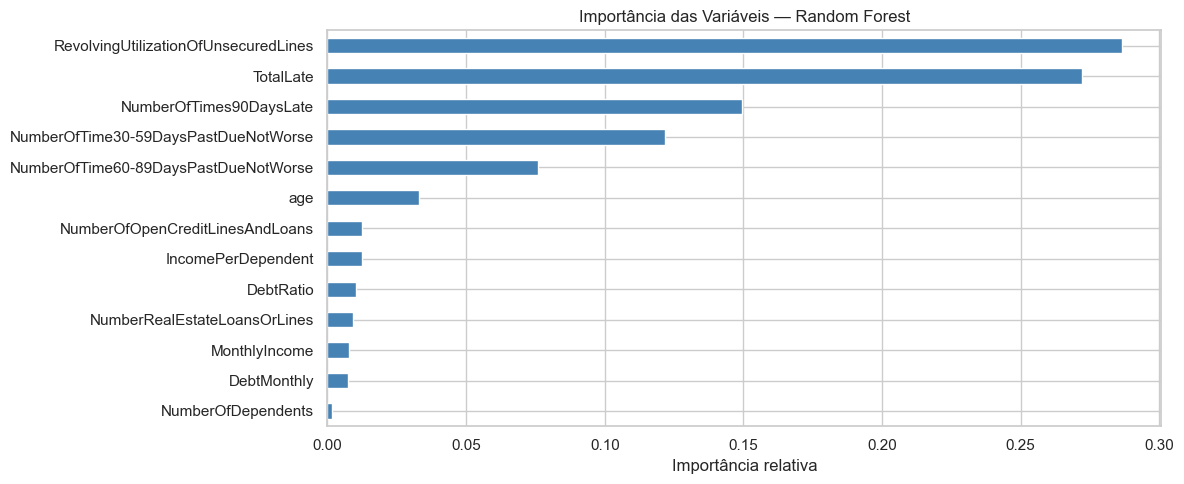

In [35]:
# Feature Importance: o modelo nos diz quais variáveis
# foram mais importantes para tomar as decisões

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== IMPORTÂNCIA DAS FEATURES ===")
print(importancias.round(4))

# Gráfico
importancias.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importância das Variáveis — Random Forest')
plt.xlabel('Importância relativa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('grafico3_feature_importance.png', dpi=150)
plt.show()

## Etapa 5 — Métricas de Avaliação

Treinar o modelo é só metade do trabalho.
Precisamos medir se ele realmente aprendeu — e fazer isso corretamente.

### Por que não usar só "acurácia"?
Se o modelo chutasse "adimplente" para todo mundo, acertaria 93%
das vezes — mas nunca identificaria um inadimplente de verdade.
Por isso usamos métricas mais sofisticadas:

- **AUC-ROC**: mede a capacidade do modelo de separar as classes.
  Vai de 0.5 (chute aleatório) a 1.0 (perfeito). Acima de 0.75 é bom.
- **Matriz de Confusão**: mostra onde o modelo acerta e onde erra.
- **Precision**: dos que o modelo disse "vai inadimplir", quantos realmente inadimpliram?
- **Recall**: dos que realmente inadimpliram, quantos o modelo identificou?
- **F1-Score**: média entre Precision e Recall — o equilíbrio entre os dois.

AUC-ROC: 0.8645


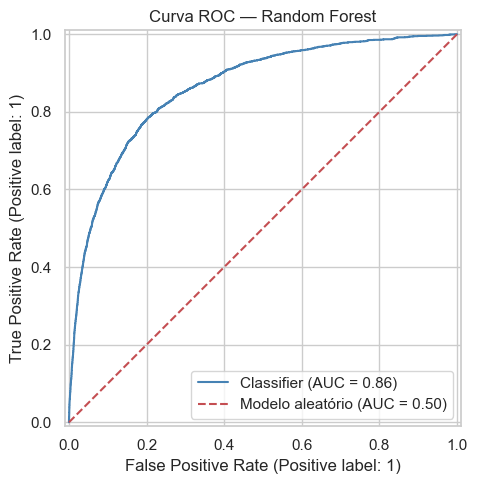

In [36]:
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

# predict_proba retorna a PROBABILIDADE de cada cliente ser inadimplente
# usamos a coluna [1] = probabilidade de ser classe 1 (inadimplente)
y_prob = modelo.predict_proba(X_test)[:, 1]

# predict retorna a classe final: 0 ou 1
y_pred = modelo.predict(X_test)

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.4f}")

# Curva ROC
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', label='Modelo aleatório (AUC = 0.50)')
ax.set_title('Curva ROC — Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('grafico4_curva_roc.png', dpi=150)
plt.show()

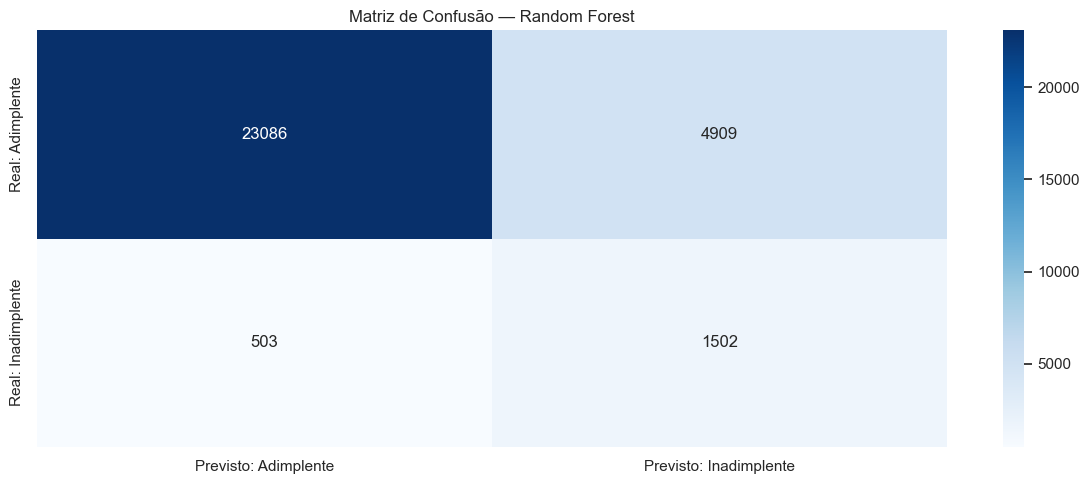

In [37]:
# A matriz de confusão mostra 4 cenários:
# Verdadeiro Negativo (VN): previu adimplente, era adimplente ✅
# Falso Positivo (FP):      previu inadimplente, era adimplente ❌
# Falso Negativo (FN):      previu adimplente, era inadimplente ❌ (o pior erro!)
# Verdadeiro Positivo (VP): previu inadimplente, era inadimplente ✅

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Adimplente', 'Previsto: Inadimplente'],
            yticklabels=['Real: Adimplente', 'Real: Inadimplente'])
plt.title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.savefig('grafico5_matriz_confusao.png', dpi=150)
plt.show()

In [38]:
# Classification Report: resumo completo das métricas
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred,
                             target_names=['Adimplente', 'Inadimplente']))

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

  Adimplente       0.98      0.82      0.90     27995
Inadimplente       0.23      0.75      0.36      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.82      0.86     30000



## Etapa 6 — Conclusões

### Sobre o modelo
O modelo Random Forest treinado com 149.999 registros do dataset
Give Me Some Credit atingiu AUC-ROC de 0.8645 — classificado como
"bom" na literatura de credit scoring.

### Principais aprendizados

1. **Comportamento de pagamento supera renda como preditor de risco**
   As 5 variáveis mais importantes foram todas ligadas a histórico
   de atrasos, respondendo por 91% da decisão do modelo.
   MonthlyIncome ficou apenas em 11º lugar.

2. **Feature Engineering fez diferença real**
   A variável TotalLate — criada manualmente somando todos os tipos
   de atraso — ficou em 2º lugar de importância (27,2%), superando
   variáveis originais do dataset.

3. **Desbalanceamento é o principal desafio em crédito**
   Com apenas 6.7% de inadimplentes, o parâmetro class_weight='balanced'
   foi essencial para que o modelo aprendesse a identificar a classe
   minoritária. Sem ele, o modelo ignoraria os inadimplentes.

4. **Recall é a métrica certa para crédito**
   O modelo detectou 75% dos inadimplentes reais. Em aplicações reais,
   deixar passar um inadimplente é mais custoso do que investigar
   um falso alarme — por isso o Recall da classe positiva é prioritário.

### Limitações e próximos passos
- Testar XGBoost para comparar performance
- Aplicar SMOTE para balanceamento sintético dos dados
- Otimizar hiperparâmetros com GridSearchCV
- Desenvolver threshold customizado para maximizar Recall

In [39]:
print("=" * 50)
print("RESUMO FINAL DO MODELO")
print("=" * 50)
print(f"\nDataset:          Give Me Some Credit (Kaggle)")
print(f"Registros:        149.999 clientes")
print(f"Features usadas:  {X.shape[1]} variáveis (3 criadas via Feature Engineering)")
print(f"Algoritmo:        Random Forest (100 árvores, max_depth=6)")
print(f"\n--- MÉTRICAS ---")
print(f"AUC-ROC:          0.8645  ✅ Bom")
print(f"Recall (inadimp): 75%     ✅ Detectou 3 em cada 4 inadimplentes")
print(f"Acurácia:         82%")
print(f"\n--- TOP 3 FEATURES ---")
print(f"1. RevolvingUtilizationOfUnsecuredLines  28.6%")
print(f"2. TotalLate (feature criada)            27.2%")
print(f"3. NumberOfTimes90DaysLate               14.9%")
print("\nModelo pronto para deploy! 🚀")

RESUMO FINAL DO MODELO

Dataset:          Give Me Some Credit (Kaggle)
Registros:        149.999 clientes
Features usadas:  13 variáveis (3 criadas via Feature Engineering)
Algoritmo:        Random Forest (100 árvores, max_depth=6)

--- MÉTRICAS ---
AUC-ROC:          0.8645  ✅ Bom
Recall (inadimp): 75%     ✅ Detectou 3 em cada 4 inadimplentes
Acurácia:         82%

--- TOP 3 FEATURES ---
1. RevolvingUtilizationOfUnsecuredLines  28.6%
2. TotalLate (feature criada)            27.2%
3. NumberOfTimes90DaysLate               14.9%

Modelo pronto para deploy! 🚀
